In [ ]:
## NLP Assignment 4 — BERT Fine-Tuning
## Dataset: News Category Dataset
### Pipeline: Raw Data → Preprocessing → Tokenization → Training → Evaluation

In [ ]:
!pip install transformers torch scikit-learn -q

In [ ]:
import re, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


In [ ]:
## Step 1 — Load Dataset

In [ ]:
from google.colab import files
files.upload()   # upload your kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rmisra/news-category-dataset
!unzip -q news-category-dataset.zip


Saving News_Category_Dataset_v3.json to News_Category_Dataset_v3.json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 26.5M/26.5M [00:02<00:00, 12.3MB/s]

replace News_Category_Dataset_v3.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
data = []
with open('News_Category_Dataset_v3.json', 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(df.shape)
df.head()

(209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
## 🔍 Step 2 — Exploratory Data Analysis

42
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUC

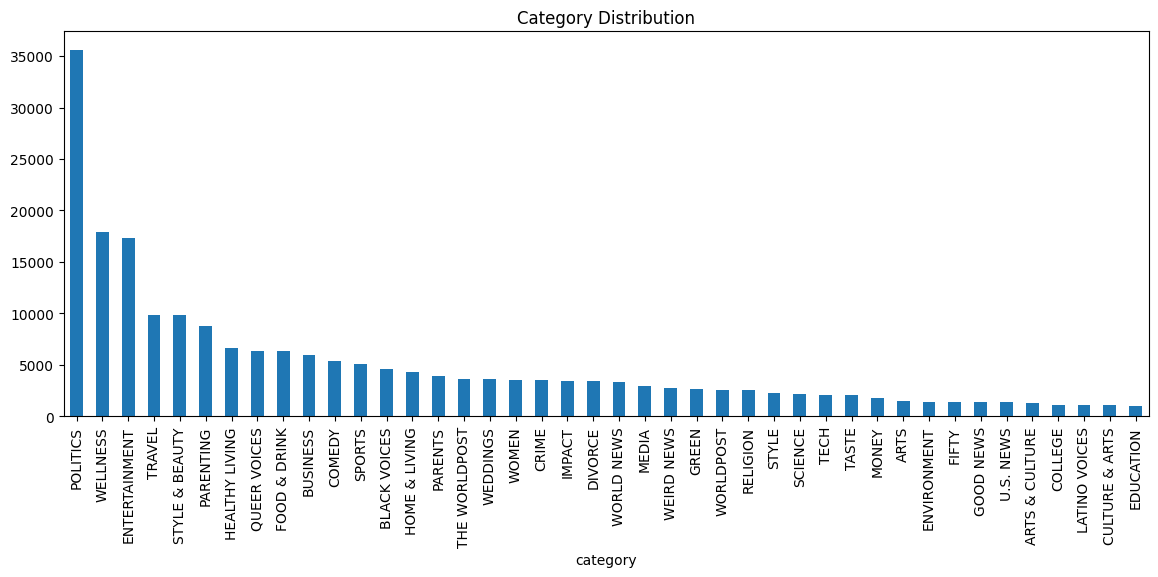

In [ ]:
print(df['category'].nunique())       # how many categories
print(df['category'].value_counts())  # count per category
df['category'].value_counts().plot(kind='bar', figsize=(14,5))
plt.title("Category Distribution")
plt.show()


In [ ]:
## Step 3 — Data Preprocessing

In [ ]:
top_cats = df['category'].value_counts().head(6).index.tolist()
df = df[df['category'].isin(top_cats)].copy()

# Sample 2000 per class to keep training fast
df = df.groupby('category').apply(lambda x: x.sample(2000, random_state=42)).reset_index(drop=True)

/tmp/ipykernel_762/1870451173.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('category').apply(lambda x: x.sample(2000, random_state=42)).reset_index(drop=True)


In [ ]:
def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)       # remove HTML
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep letters/digits
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df['text'] = df['headline'].fillna('') + ' ' + df['short_description'].fillna('')
df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.len() > 10].reset_index(drop=True)

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
NUM_CLASSES = len(le.classes_)
print(dict(enumerate(le.classes_)))  # see which number = which category

{0: 'ENTERTAINMENT', 1: 'PARENTING', 2: 'POLITICS', 3: 'STYLE & BEAUTY', 4: 'TRAVEL', 5: 'WELLNESS'}


In [ ]:
## Step 4 — Train / Validation / Test Split

In [ ]:
X, y = df['text'].tolist(), df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 8400 | Val: 1800 | Test: 1800


In [ ]:
## Step 5 — Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN    = 128
BATCH_SIZE = 16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
##Step 6 — Dataset & DataLoader


In [ ]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        # Tokenize everything at once during init
        self.encodings = tokenizer(
            texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
train_loader = DataLoader(NewsDataset(X_train, y_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(NewsDataset(X_val,   y_val,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(NewsDataset(X_test,  y_test,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [ ]:
## Step 7 — Training & Evaluation Functions


In [ ]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        lbls  = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        correct    += (out.logits.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            preds = out.logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    return {
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted'),
        'recall':    recall_score(all_labels, all_preds, average='weighted'),
        'f1':        f1_score(all_labels, all_preds, average='weighted'),
        'preds':     all_preds,
        'labels':    all_labels
    }

In [ ]:

##  Experiment 1 — Freeze ALL BERT Layers

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=NUM_CLASSES).to(device)

# Freeze everything except classifier
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 4,614


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=NUM_CLASSES).to(device)

# Freeze all first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder layers + classifier
for name, param in model.named_parameters():
    if 'encoder.layer.10' in name or 'encoder.layer.11' in name or 'classifier' in name:
        param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=NUM_CLASSES).to(device)
# All layers trainable by default — nothing to freeze


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
EPOCHS = 3
LR     = 2e-5

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps)

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    val_metrics     = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Val F1: {val_metrics['f1']:.4f}")

# Final test evaluation
test_metrics_exp1 = evaluate(model, test_loader)  # rename for each experiment
print(test_metrics_exp1)